In [2]:
#------------Import Libraries-------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torchvision.models import MobileNet_V2_Weights
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# --------------Device setup-------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
# ----------Image settings------------
IMG_SIZE = 224
BATCH_SIZE = 16

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: 224
Batch Size: 16


In [5]:
#--------Data Preprocesing-----
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    ToTensor()
)


In [6]:
#----------Load dataset-----------
dataset = datasets.ImageFolder(root="dataset/train", transform=transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
Total Images: 2900


In [7]:
#----------split dataset----------
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

print("Training Images:", len(train_data))
print("Validation Images:", len(val_data))
print("Test Images:", len(test_data))

Training Images: 2029
Validation Images: 580
Test Images: 291


In [8]:
#------------Data loaders------------
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

for images, labels in train_loader:
    print("Image Batch Shape:", images.shape)
    print("Labels:", labels)
    break

Image Batch Shape: torch.Size([16, 3, 224, 224])
Labels: tensor([0, 1, 2, 0, 1, 2, 0, 1, 2, 2, 3, 3, 1, 3, 1, 2])


In [9]:
#----------mobilenetv2 model-------------
model = models.mobilenet_v2(
    weights=MobileNet_V2_Weights.DEFAULT
)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
model.classifier[1] = nn.Linear(model.last_channel, 4)

model = model.to(device)

print("Model running on:", device)
print(model.classifier)

Model running on: cpu
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [10]:
#-----------Loss function & optimizer------
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Loss Function:")
print(criterion)

print("Optimizer:")
print(optimizer)

Loss Function:
CrossEntropyLoss()
Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [11]:
#-------------Model Training----------
epochs = 5

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1
Train Loss: 81.8631
Validation Accuracy: 83.28%
Epoch 2
Train Loss: 47.4662
Validation Accuracy: 88.79%
Epoch 3
Train Loss: 41.7813
Validation Accuracy: 86.72%
Epoch 4
Train Loss: 37.4501
Validation Accuracy: 92.41%
Epoch 5
Train Loss: 33.4953
Validation Accuracy: 92.24%


In [12]:
#-------Model evaluation--------
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

print("Test Accuracy:", accuracy * 100)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:", cm)

print(classification_report(all_labels, all_preds))

Test Accuracy: 89.00343642611683
Confusion Matrix: [[64  0  0  0]
 [ 4 63  0  0]
 [ 0  0 76 10]
 [ 0  0 18 56]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        64
           1       1.00      0.94      0.97        67
           2       0.81      0.88      0.84        86
           3       0.85      0.76      0.80        74

    accuracy                           0.89       291
   macro avg       0.90      0.90      0.90       291
weighted avg       0.89      0.89      0.89       291



In [13]:
#------------Decision Fusion Logic-----------

def get_fatigue_level(pred):

    # Open
    if pred == 1:
        return "Alert"

    # no-yawn
    elif pred == 2:
        return "Alert"

    # yawn
    elif pred == 3:
        return "Mild Fatigue"

    # Closed
    elif pred == 0:
        return "Severe Fatigue"


fatigue_levels = [get_fatigue_level(p) for p in all_preds]

print(fatigue_levels[:10])

['Severe Fatigue', 'Mild Fatigue', 'Mild Fatigue', 'Alert', 'Mild Fatigue', 'Alert', 'Alert', 'Severe Fatigue', 'Severe Fatigue', 'Alert']


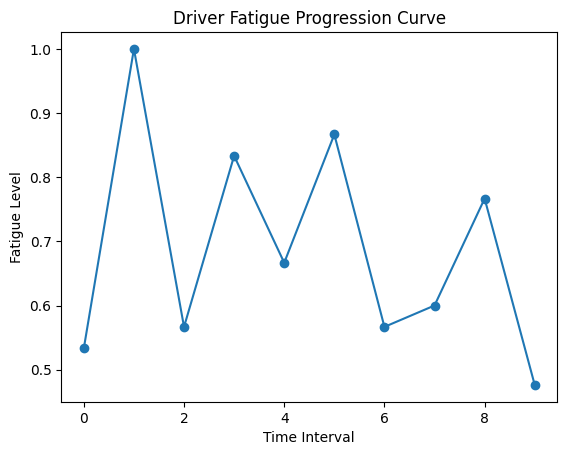

In [14]:
#----------Fatigue Progression Curve------------

fatigue_stages = []

for p in all_preds:

    # Closed → Severe Fatigue
    if p == 0:
        fatigue_stages.append(2)

    # Open → Alert
    elif p == 1:
        fatigue_stages.append(0)

    # no-yawn → Alert
    elif p == 2:
        fatigue_stages.append(0)

    # yawn → Mild Fatigue
    elif p == 3:
        fatigue_stages.append(1)

# Time interval size
interval_size = 30

avg_fatigue = []
time_intervals = []

for i in range(0, len(fatigue_stages), interval_size):

    chunk = fatigue_stages[i:i+interval_size]

    if len(chunk) == 0:
        continue

    avg = sum(chunk) / len(chunk)

    avg_fatigue.append(avg)
    time_intervals.append(i // interval_size)

# Plot graph
plt.plot(time_intervals, avg_fatigue, marker='o')

plt.xlabel("Time Interval")
plt.ylabel("Fatigue Level")

plt.title("Driver Fatigue Progression Curve")

plt.show()

In [15]:
torch.save(model.state_dict(), "model.pth")
print("✅ Model saved successfully")

✅ Model saved successfully
